In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- 1. LOAD DATA & INITIAL CLEANING ---
df = pd.read_csv("C:/Users/ThinkPad/Project_4/diamonds.csv")

# Convert zero/invalid values in dimensions to NaN and impute with median
for col in ['x', 'y', 'z']:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())
# Handle any other missing values
df = df.dropna()

# --- 2. FEATURE ENGINEERING & CURRENCY CONVERSION ---
# Convert price from USD to INR (using a standard baseline exchange rate of ~83.5)
USD_TO_INR_RATE = 83.5
df['price_usd'] = df['price']  # Keep a backup if needed
df['price'] = df['price'] * USD_TO_INR_RATE

# Derived features
df['Volume'] = df['x'] * df['y'] * df['z']
df['Price_per_Carat'] = df['price'] / df['carat']
df['Dimension_Ratio'] = (df['x'] + df['y']) / (2 * df['z'])

# Carat Category spacing binning
def get_carat_category(carat):
    if carat < 0.5: return 'Light'
    elif 0.5 <= carat <= 1.5: return 'Medium'
    else: return 'Heavy'

df['Carat_Category'] = df['carat'].apply(get_carat_category)
df

,carat,cut,color,clarity,depth,table,price,x,y,z,price_usd,Volume,Price_per_Carat,Dimension_Ratio,Carat_Category
0,0.23,Ideal,E,SI2,61.5,55.0,27221.0,3.95,3.98,2.43,326,38.202030,118352.173913,1.631687,Light
1,0.21,Premium,E,SI1,59.8,61.0,27221.0,3.89,3.84,2.31,326,34.505856,129623.809524,1.673160,Light
2,0.23,Good,E,VS1,56.9,65.0,27304.5,4.05,4.07,2.31,327,38.076885,118715.217391,1.757576,Light
3,0.29,Premium,I,VS2,62.4,58.0,27889.0,4.20,4.23,2.63,334,46.724580,96168.965517,1.602662,Light
4,0.31,Good,J,SI2,63.3,58.0,27972.5,4.34,4.35,2.75,335,51.917250,90233.870968,1.580000,Light
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,230209.5,5.75,5.76,3.50,2757,115.920000,319735.416667,1.644286,Medium
53936,0.72,Good,D,SI1,63.1,55.0,230209.5,5.69,5.75,3.61,2757,118.110175,319735.416667,1.584488,Medium
53937,0.70,Very Good,D,SI1,62.8,60.0,230209.5,5.66,5.68,3.56,2757,114.449728,328870.714286,1.592697,Medium
53938,0.86,Premium,H,SI2,61.0,58.0,230209.5,6.15,6.12,3.74,2757,140.766120,267685.465116,1.640374,Medium


In [36]:
# --- 1. OUTLIER HANDLING (IQR METHOD) ---
numerical_cols = ['carat', 'price', 'x', 'y', 'z', 'Volume', 'depth', 'table']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filtering out extreme outliers
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# --- 2. SKEWNESS CHECK & LOG TRANSFORMATION ---
print("Skewness before transformation:\n", df[numerical_cols].skew())

# Apply Log Transformation to highly skewed target and weight features
df['price_log'] = np.log1p(df['price'])
df['carat_log'] = np.log1p(df['carat'])

Skewness before transformation:
 carat     0.677262
price     1.140328
x         0.251815
y         0.245364
z         0.247923
Volume    0.676678
depth    -0.198150
table     0.397300
dtype: float64


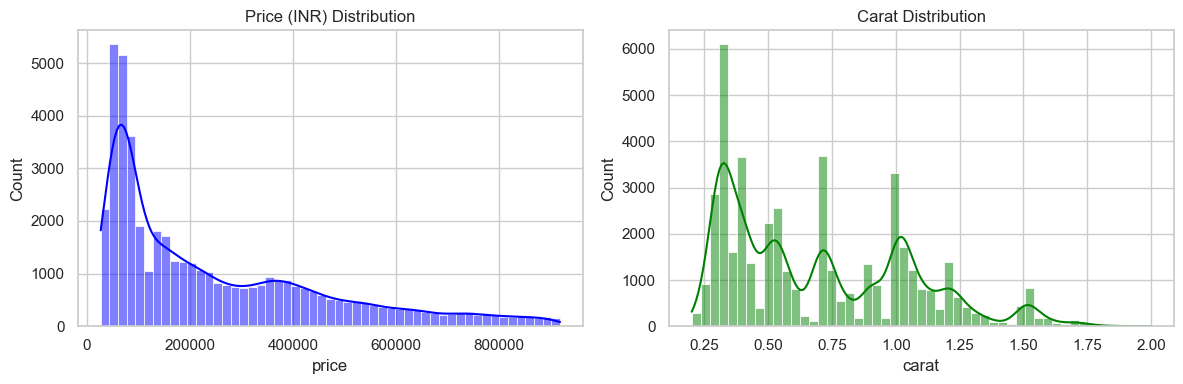

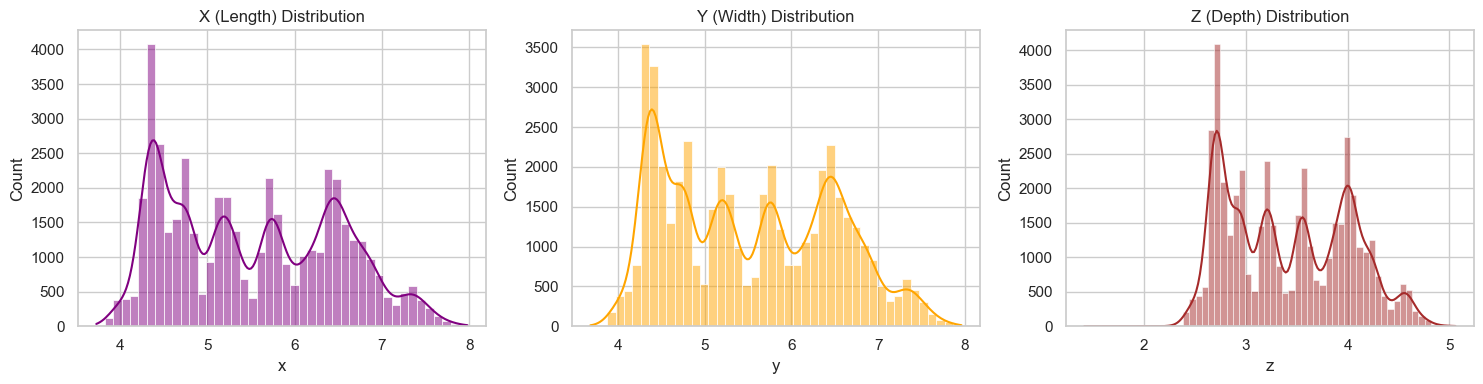

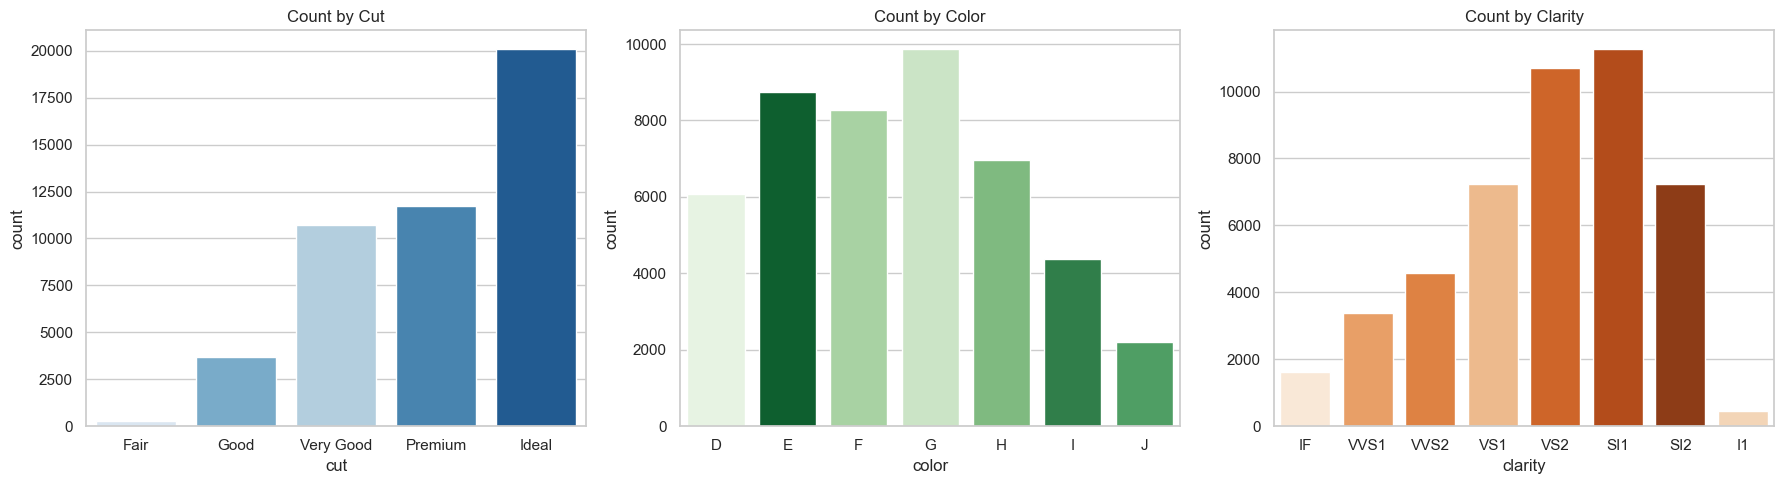

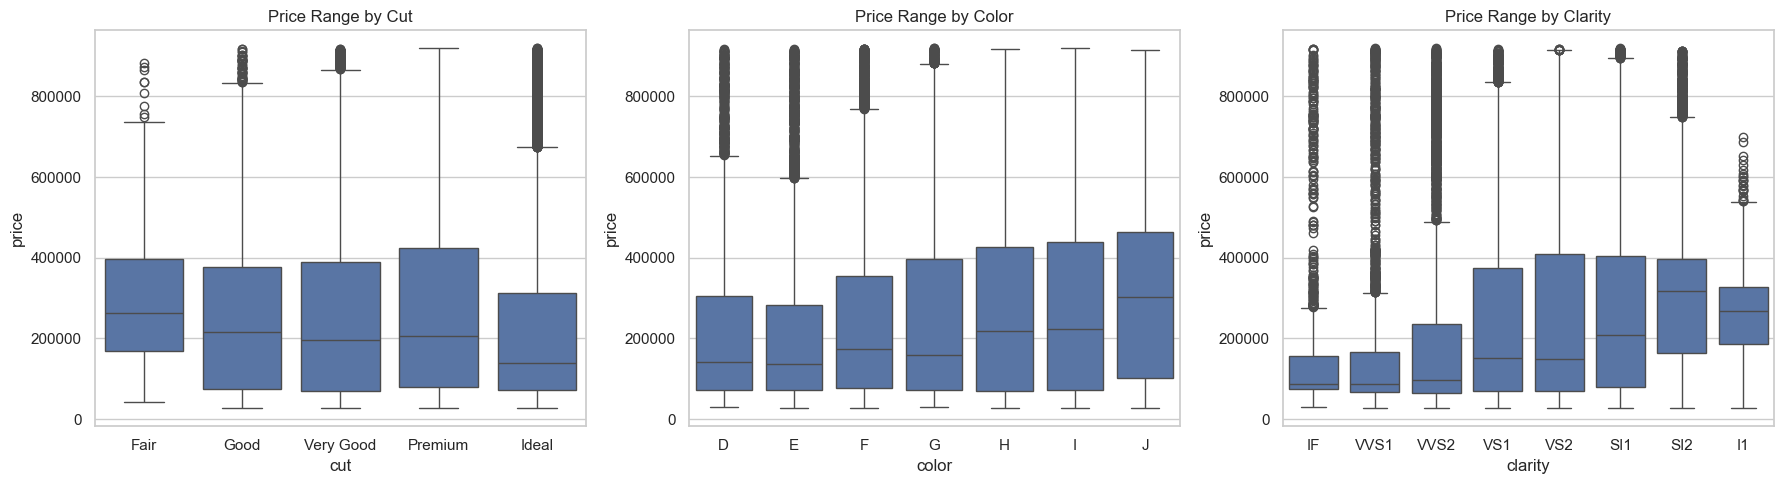

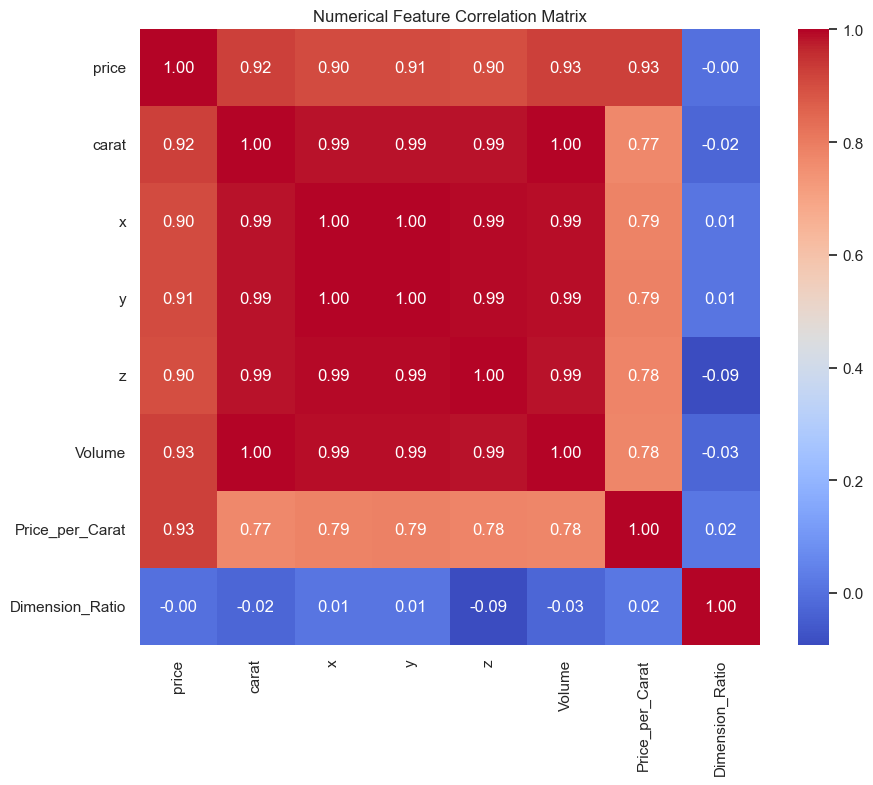

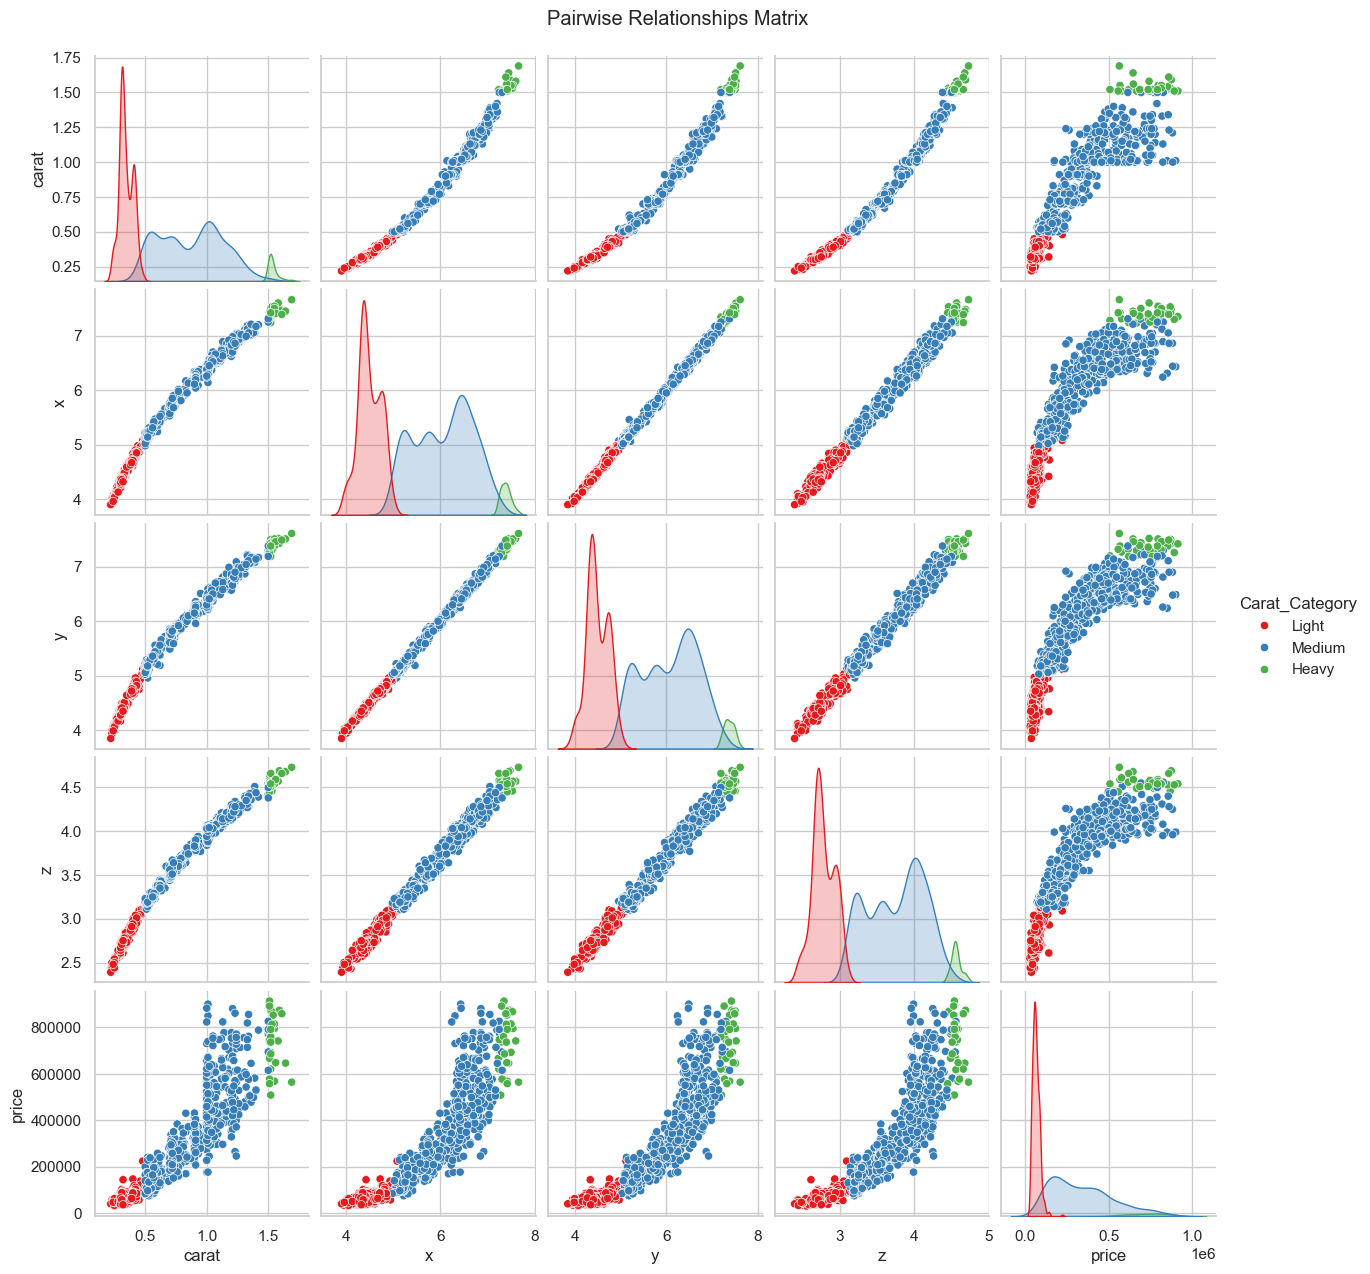

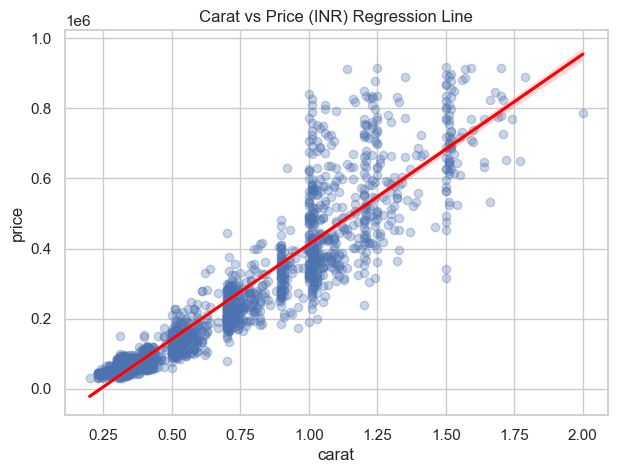

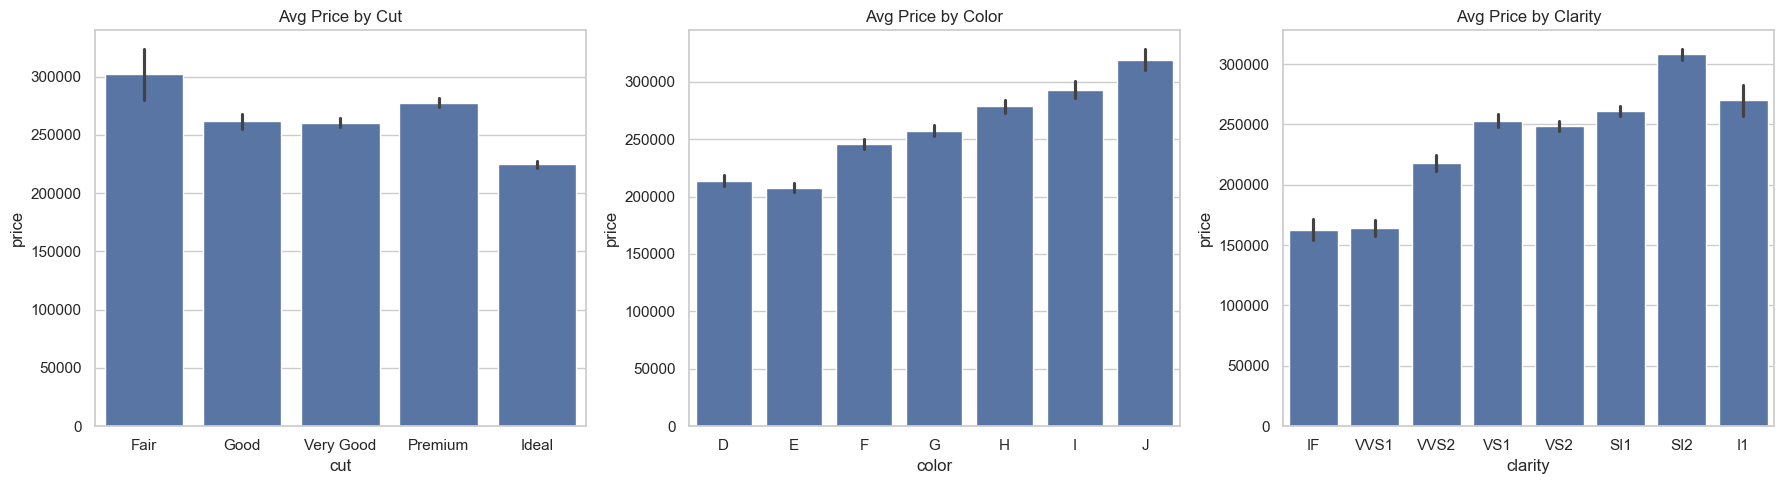

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the requested theme
sns.set_theme(style="whitegrid")

# Define numerical columns for the heatmap and pairplot
# (Includes your new derived features from the earlier step!)
numerical_cols = ['price', 'carat', 'x', 'y', 'z', 'Volume', 'Price_per_Carat', 'Dimension_Ratio']

# ==========================================
# 1. Distribution Plots (Price, Carat, x, y, z)
# ==========================================
# Price and Carat
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='blue').set_title('Price (INR) Distribution')
plt.subplot(1, 2, 2)
sns.histplot(df['carat'], kde=True, color='green').set_title('Carat Distribution')
plt.tight_layout()
plt.show()

# Dimensions (x, y, z)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['x'], kde=True, color='purple', ax=axes[0]).set_title('X (Length) Distribution')
sns.histplot(df['y'], kde=True, color='orange', ax=axes[1]).set_title('Y (Width) Distribution')
sns.histplot(df['z'], kde=True, color='brown', ax=axes[2]).set_title('Z (Depth) Distribution')
plt.tight_layout()
plt.show()

# ==========================================
# 2. Count Plots for Categorical Features
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Added hue='cut' and legend=False
sns.countplot(data=df, x='cut', ax=axes[0], order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], palette='Blues_r', hue='cut', legend=False)
# Added hue='color' and legend=False
sns.countplot(data=df, x='color', ax=axes[1], order=['D', 'E', 'F', 'G', 'H', 'I', 'J'], palette='Greens_r', hue='color', legend=False)
# Added hue='clarity' and legend=False
sns.countplot(data=df, x='clarity', ax=axes[2], order=['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'], palette='Oranges_r', hue='clarity', legend=False)
axes[0].set_title('Count by Cut')
axes[1].set_title('Count by Color')
axes[2].set_title('Count by Clarity')
plt.tight_layout()
plt.show()

# ==========================================
# 3. Price Variation Using Boxplots
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='cut', y='price', ax=axes[0], order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'])
sns.boxplot(data=df, x='color', y='price', ax=axes[1], order=['D', 'E', 'F', 'G', 'H', 'I', 'J'])
sns.boxplot(data=df, x='clarity', y='price', ax=axes[2], order=['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'])
axes[0].set_title('Price Range by Cut')
axes[1].set_title('Price Range by Color')
axes[2].set_title('Price Range by Clarity')
plt.tight_layout()
plt.show()

# ==========================================
# 4. Correlation Heatmap
# ==========================================
plt.figure(figsize=(10, 8))
# Added .corr() fix to ensure only numeric matrix is passed
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation Matrix')
plt.show()

# ==========================================
# 5. Scatterplot Matrix / Pairwise Relationships
# ==========================================
# Using a sample of 1000 rows so your computer doesn't freeze processing 50k+ rows!
sns.pairplot(df.sample(1000), vars=['carat', 'x', 'y', 'z', 'price'], hue='Carat_Category', palette='Set1')
plt.suptitle('Pairwise Relationships Matrix', y=1.02)
plt.show()

# ==========================================
# 6. Carat vs. Price Regression Line
# ==========================================
plt.figure(figsize=(7, 5))
sns.regplot(data=df.sample(2000), x='carat', y='price', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Carat vs Price (INR) Regression Line')
plt.show()

# ==========================================
# 7. Average Price Per Category (Bar Plots)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=df, x='cut', y='price', ax=axes[0], order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'])
sns.barplot(data=df, x='color', y='price', ax=axes[1], order=['D', 'E', 'F', 'G', 'H', 'I', 'J'])
sns.barplot(data=df, x='clarity', y='price', ax=axes[2], order=['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'])
axes[0].set_title('Avg Price by Cut')
axes[1].set_title('Avg Price by Color')
axes[2].set_title('Avg Price by Clarity')
plt.tight_layout()
plt.show()

In [38]:
# --- 1. ORDINAL ENCODING ---
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] # Worst to Best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] # Worst to Best

encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])
df[['cut', 'color', 'clarity']] = encoder.fit_transform(df[['cut', 'color', 'clarity']])

# One-hot encode the engineered nominal column
df = pd.get_dummies(df, columns=['Carat_Category'], drop_first=True)

# --- 2. MULTICOLLINEARITY (VIF ANALYSIS) ---
# Selecting base physical features to test structural overlap
features_for_vif = ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut', 'color', 'clarity']
X_vif = df[features_for_vif].dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("\nVariance Inflation Factor Results:\n", vif_data)


Variance Inflation Factor Results:
    Feature           VIF
0    carat    190.847244
1    depth   1625.696501
2    table    996.106650
3        x  14166.519298
4        y  12064.613237
5        z   6079.098202
6      cut     13.521368
7    color      5.859067
8  clarity      5.732659


In [39]:
import numpy as np
import pandas as pd
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Prepare Predictor Metrics ---
# Dropping raw cost references to avoid catastrophic target leaks 
drop_cols = ['price', 'price_log', 'Price_per_Carat', 'price_usd', 'Carat_Category']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['price_log'] # Using robust log-transformed target

# Train-Test Validation Split (80-20 Rule)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Initialize Classic ML Models ---
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5)
}

# --- Optional Section: Build & Append Neural Network (ANN) Regressor ---
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    
    ann_model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1) # Linear activation for log continuous calculation output
    ])
    ann_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    ann_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)
    
    # We will score this manually below during compilation loop
except ImportError:
    print("TensorFlow package not detected. Proceeding with standard baseline architectures.")

# --- Evaluation Loop ---
results_matrix = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    log_preds = model.predict(X_test)
    
    # Invert log transform back to raw INR values for evaluation clarity
    true_inr = np.expm1(y_test)
    pred_inr = np.expm1(log_preds)
    
    mae = mean_absolute_error(true_inr, pred_inr)
    mse = mean_squared_error(true_inr, pred_inr)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_inr, pred_inr)
    
    results_matrix[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

print("\n--- Regression Benchmark Standings ---")
print(pd.DataFrame(results_matrix).T)

# Save the absolute peak performer (e.g. Random Forest or customized XGBoost integration)
os.makedirs('models', exist_ok=True)
with open('models/best_regression_model.pkl', 'wb') as f:
    pickle.dump(models["Random Forest"], f)

TensorFlow package not detected. Proceeding with standard baseline architectures.

--- Regression Benchmark Standings ---
                              MAE           MSE          RMSE        R2
Linear Regression    25833.503412  1.977241e+09  44466.183124  0.958533
Decision Tree        18887.309373  1.154252e+09  33974.286193  0.975793
Random Forest        16363.954457  8.506020e+08  29165.081815  0.982161
K-Nearest Neighbors  22745.691345  1.545727e+09  39315.736931  0.967583


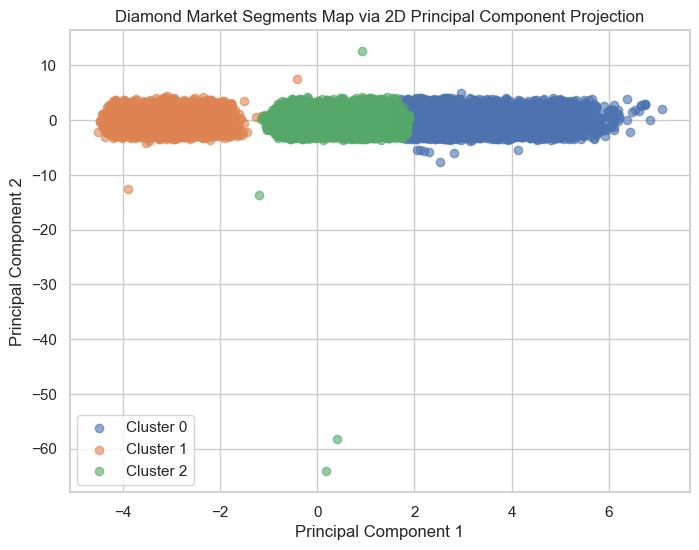

In [40]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Scale numerical structures before executing distances matrix calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Elbow Method Execution Hook ---
wcss = []
for i in range(1, 8):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Save optimal model configurations matching target requirements (e.g., K=3)
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster_ID'] = final_kmeans.fit_predict(X_scaled)

# --- Dimensionality Reduction via PCA for Visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA_1'] = X_pca[:, 0]
df['PCA_2'] = X_pca[:, 1]

# 2D Cluster Visual Projection Map
plt.figure(figsize=(8, 6))
for cluster in range(optimal_k):
    subset = df[df['Cluster_ID'] == cluster]
    plt.scatter(subset['PCA_1'], subset['PCA_2'], label=f'Cluster {cluster}', alpha=0.6)
plt.title('Diamond Market Segments Map via 2D Principal Component Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# Export cluster configuration models for frontend applications
with open('models/best_clustering_model.pkl', 'wb') as f:
    pickle.dump(final_kmeans, f)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)